# 🌳📊 Decision Tree vs Logistic Regression Analysis

In this project, we explore two powerful machine learning models — **Logistic Regression** and **Decision Tree Classifier** — to understand how well they can predict outcomes based on the given dataset.

The goal is not only to build accurate models, but also to:
- 🔍 Understand how each model makes decisions  
- 📈 Compare their performance using key metrics  
- ⚖️ Evaluate which model is more suitable for real-world application  

Logistic Regression provides a **statistical and interpretable approach**, while Decision Trees offer a **visual and rule-based method** for decision-making.

By the end of this analysis, we will determine which model performs better and, more importantly, **why**.

In [1]:
import pandas as pd 
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.drop(columns=['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin','Embarked'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [3]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [4]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
dtype: int64

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [6]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns

<Axes: xlabel='Sex'>

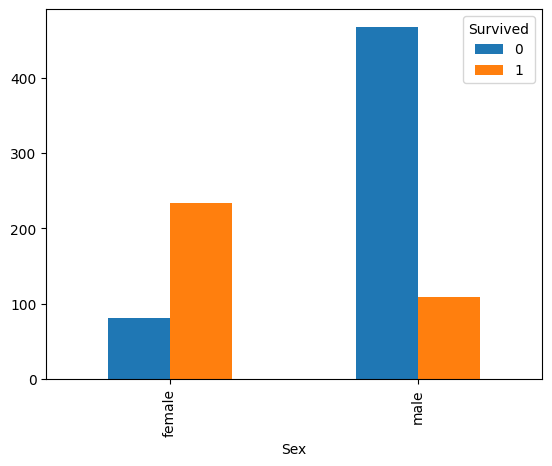

In [8]:
pd.crosstab(df.Sex, df.Survived).plot(kind='bar')


<Axes: xlabel='Survived', ylabel='Age'>

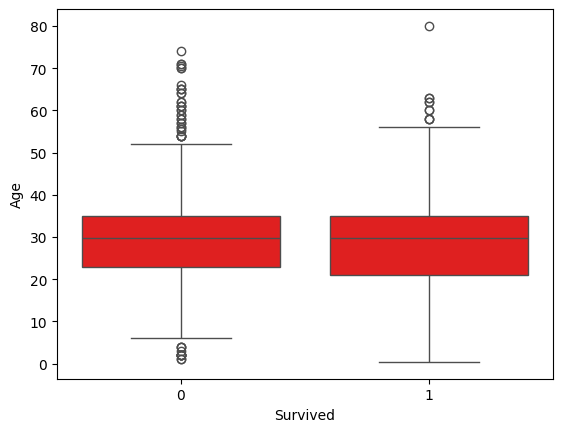

In [9]:
sns.boxplot(x='Survived', y='Age',data=df ,color='red')


In [10]:
dummies = pd.get_dummies(df, dtype=int)
dummies.head()

,Survived,Pclass,Age,Fare,Sex_female,Sex_male
0,0,3,22.0,7.2500,0,1
1,1,1,38.0,71.2833,1,0
2,1,3,26.0,7.9250,1,0
3,1,1,35.0,53.1000,1,0
4,0,3,35.0,8.0500,0,1


In [11]:
corr=dummies.corr()
corr

,Survived,Pclass,Age,Fare,Sex_female,Sex_male
Survived,1.000000,-0.338481,-0.069809,0.257307,0.543351,-0.543351
Pclass,-0.338481,1.000000,-0.331339,-0.549500,-0.131900,0.131900
Age,-0.069809,-0.331339,1.000000,0.091566,-0.084153,0.084153
Fare,0.257307,-0.549500,0.091566,1.000000,0.182333,-0.182333
Sex_female,0.543351,-0.131900,-0.084153,0.182333,1.000000,-1.000000
Sex_male,-0.543351,0.131900,0.084153,-0.182333,-1.000000,1.000000


<Axes: >

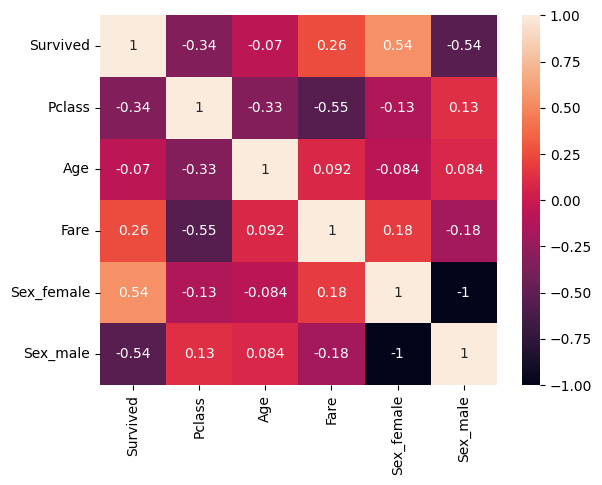

In [12]:
sns.heatmap(corr, annot= True)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X=dummies.drop(columns=['Survived'])
y=dummies['Survived']

In [15]:
X_train, X_test, y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=9)

In [16]:
X_train.shape

(712, 5)

In [17]:
X_test.shape

(179, 5)

In [18]:
from sklearn import tree 

In [19]:
model= tree.DecisionTreeClassifier()

In [20]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [42]:
y_pred1=model.predict(X_test)

In [43]:
results = pd.DataFrame({'Actual': y_test, 'Results':y_pred1})
results.head(15)

,Actual,Results
132,0,0
561,0,0
548,0,0
493,0,0
431,1,1
876,0,0
701,1,1
45,0,0
193,1,1
813,0,1


In [44]:
model.score(X_test, y_test)

0.7486033519553073

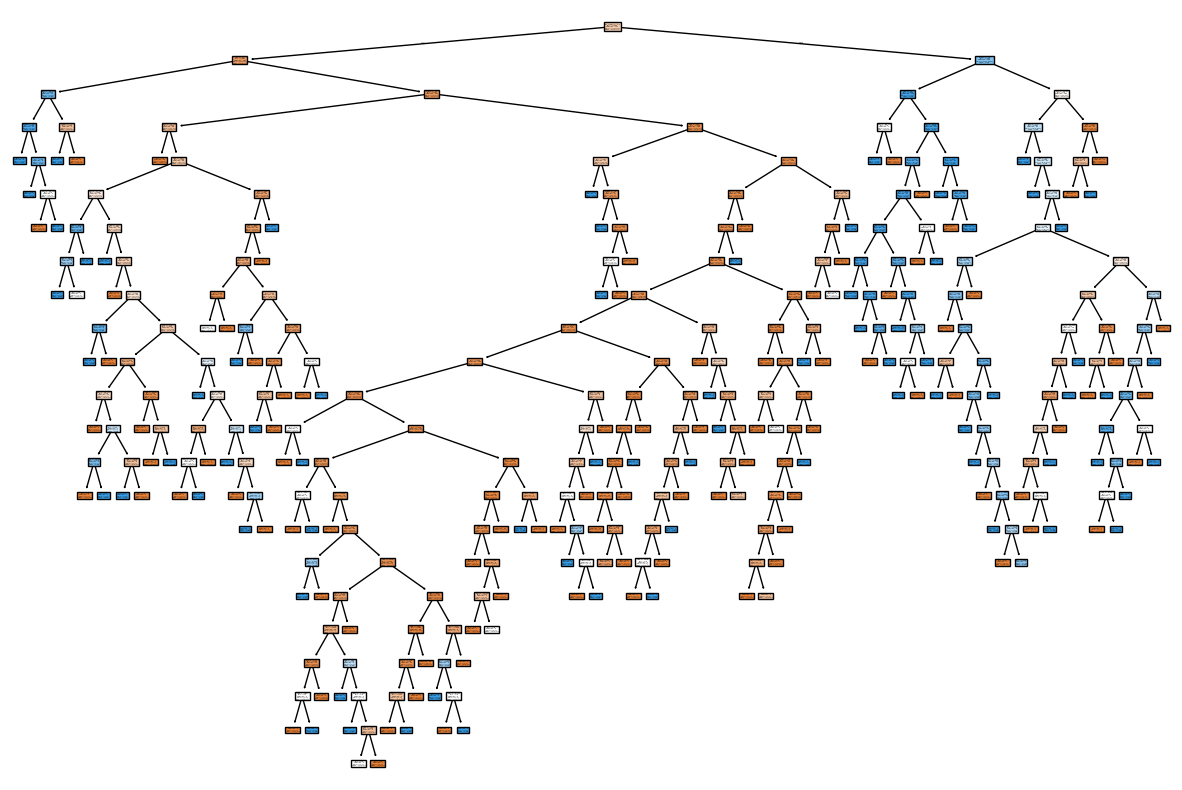

In [45]:
plt.figure(figsize=(15, 10))
tree.plot_tree(model, feature_names = X_train.columns,class_names=['Survived', 'Died'],filled  = True )              
plt.show()

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
mod = LogisticRegression()

In [48]:
mod.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [49]:
y_pred = model.predict(X_test)

In [50]:
Results2 = pd.DataFrame({'Actual':y_test, 'Results': y_pred})
Results2.head()

,Actual,Results
132,0,0
561,0,0
548,0,0
493,0,0
431,1,1


In [51]:
mod.score(X_test, y_test)

0.7653631284916201

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("Tree:", accuracy_score(y_test, y_pred1))

Logistic: 0.7486033519553073
Tree: 0.7486033519553073


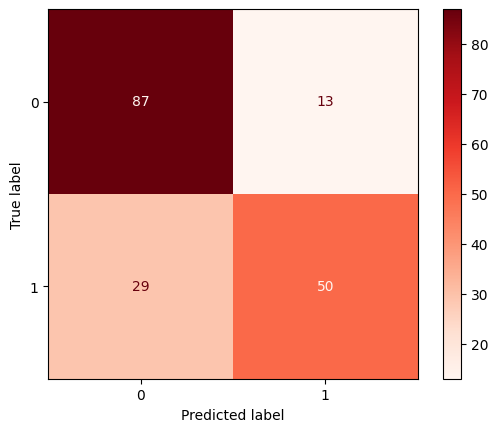

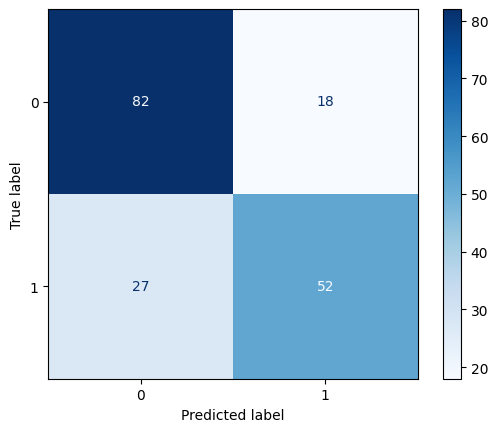

In [61]:
##🔍 Confusion Matrix

#The confusion matrix provides a deeper look into how the model is performing.

#It breaks predictions into four categories:
#- ✅ True Positives (correctly predicted positives)
#- ✅ True Negatives (correctly predicted negatives)
#- ❌ False Positives (incorrect positive predictions)
#- ❌ False Negatives (missed positive cases)

#The confusion matrix helps us understand where the model is making mistakes.

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(mod, X_test, y_test,  cmap='Reds')
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,  cmap='Blues')

# 🧠✨ Conclusion

In this analysis, we compared Logistic Regression and Decision Tree models to evaluate their performance and interpretability.

The **Decision Tree model** provided a clear and visual representation of decision-making, making it easy to interpret and understand. However, it may be prone to overfitting, especially when the tree becomes too complex.

On the other hand, **Logistic Regression** offered a more stable and statistically grounded approach. Although it lacks visual interpretability, it performs well when the relationship between variables is more linear.

From the results:
- 📊 both models had the same accuracy but from the confusion matrix **Logistic Regression** is slightly better  
- 🔍 The confusion matrix revealed how each model handled errors  
- ⚖️ Trade-offs between interpretability and performance became evident  

### 🚀 Final Insight:
The choice of model depends on the problem:
- If **interpretability and decision rules** are important → Decision Tree 🌳  
- If **stability and generalization** are preferred → Logistic Regression 📈  

Ultimately, this comparison highlights that **the best model is not always the most accurate one, but the one most suitable for the problem context**.